In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [29]:
df= pd .read_csv(r'C:\AC Office Chakwal\Python\obesitychecker project\dataset\ObesityDataSet_raw_and_data_sinthetic.csv')
print(df)

            Age  Gender    Height      Weight        CALC FAVC  FCVC  NCP  \
0     21.000000  Female  1.620000   64.000000          no   no   2.0  3.0   
1     21.000000  Female  1.520000   56.000000   Sometimes   no   3.0  3.0   
2     23.000000    Male  1.800000   77.000000  Frequently   no   2.0  3.0   
3     27.000000    Male  1.800000   87.000000  Frequently   no   3.0  3.0   
4     22.000000    Male  1.780000   89.800000   Sometimes   no   2.0  1.0   
...         ...     ...       ...         ...         ...  ...   ...  ...   
2106  20.976842  Female  1.710730  131.408528   Sometimes  yes   3.0  3.0   
2107  21.982942  Female  1.748584  133.742943   Sometimes  yes   3.0  3.0   
2108  22.524036  Female  1.752206  133.689352   Sometimes  yes   3.0  3.0   
2109  24.361936  Female  1.739450  133.346641   Sometimes  yes   3.0  3.0   
2110  23.664709  Female  1.738836  133.472641   Sometimes  yes   3.0  3.0   

      SCC SMOKE      CH2O family_history_with_overweight       FAF       TU

In [30]:
print(df.describe())

               Age       Height       Weight         FCVC          NCP  \
count  2111.000000  2111.000000  2111.000000  2111.000000  2111.000000   
mean     24.312600     1.701677    86.586058     2.419043     2.685628   
std       6.345968     0.093305    26.191172     0.533927     0.778039   
min      14.000000     1.450000    39.000000     1.000000     1.000000   
25%      19.947192     1.630000    65.473343     2.000000     2.658738   
50%      22.777890     1.700499    83.000000     2.385502     3.000000   
75%      26.000000     1.768464   107.430682     3.000000     3.000000   
max      61.000000     1.980000   173.000000     3.000000     4.000000   

              CH2O          FAF          TUE  
count  2111.000000  2111.000000  2111.000000  
mean      2.008011     1.010298     0.657866  
std       0.612953     0.850592     0.608927  
min       1.000000     0.000000     0.000000  
25%       1.584812     0.124505     0.000000  
50%       2.000000     1.000000     0.625350  
75% 

In [31]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   object 
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   object 
 12  FAF                             21

In [32]:
print("Missing Values in each column:\n",df.isnull().sum())
print("Total Missing Values in the dataset:",df.isnull().sum().sum())


Missing Values in each column:
 Age                               0
Gender                            0
Height                            0
Weight                            0
CALC                              0
FAVC                              0
FCVC                              0
NCP                               0
SCC                               0
SMOKE                             0
CH2O                              0
family_history_with_overweight    0
FAF                               0
TUE                               0
CAEC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64
Total Missing Values in the dataset: 0


In [33]:
print(df.value_counts() )

Age   Gender  Height  Weight  CALC        FAVC  FCVC  NCP  SCC  SMOKE  CH2O  family_history_with_overweight  FAF  TUE  CAEC        MTRANS                 NObeyesdad         
21.0  Male    1.62    70.0    Sometimes   yes   2.0   1.0  no   no     3.0   no                              1.0  0.0  no          Public_Transportation  Overweight_Level_I     15
      Female  1.52    42.0    Sometimes   yes   3.0   1.0  no   no     1.0   no                              0.0  0.0  Frequently  Public_Transportation  Insufficient_Weight     4
                                          no    3.0   1.0  no   no     1.0   no                              0.0  0.0  Frequently  Public_Transportation  Insufficient_Weight     2
18.0  Male    1.72    53.0    Sometimes   yes   2.0   3.0  no   no     2.0   yes                             0.0  2.0  Sometimes   Public_Transportation  Insufficient_Weight     2
25.0  Female  1.57    55.0    Sometimes   yes   2.0   1.0  no   no     2.0   no                           

In [34]:
print("Duplicated Rows in the dataset:",df.duplicated().sum())

Duplicated Rows in the dataset: 24


In [35]:
print("Shape of the dataset before dropping duplicates:",df.shape)
df.drop_duplicates(inplace=True)
print("Duplicated Rows in the dataset after dropping duplicates:",df.duplicated().sum())
print("Shape of the dataset after dropping duplicates:",df.shape)

Shape of the dataset before dropping duplicates: (2111, 17)
Duplicated Rows in the dataset after dropping duplicates: 0
Shape of the dataset after dropping duplicates: (2087, 17)


In [36]:
numerical_cols =['Age','Height','Weight','FCVC','NCP', 'CH2O', 'FAF', 'TUE']
def detect_outliers_iqr(data,col):
    Q1=data[col].quantile(0.25)
    Q3=data[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("Outliers count per column ")
for col in numerical_cols:
    count, lower, upper = detect_outliers_iqr(df, col)
    print (f"{col}: {count} outliers | valid range: [{lower:.2f}, {upper:.2f}]")


Outliers count per column 
Age: 167 outliers | valid range: [10.79, 35.13]
Height: 1 outliers | valid range: [1.42, 1.98]
Weight: 1 outliers | valid range: [2.98, 171.04]
FCVC: 0 outliers | valid range: [0.50, 4.50]
NCP: 577 outliers | valid range: [2.24, 3.45]
CH2O: 0 outliers | valid range: [0.28, 3.78]
FAF: 0 outliers | valid range: [-2.21, 4.01]
TUE: 0 outliers | valid range: [-1.50, 2.50]


### DECISION: No capping applied.
#### Reason: Outliers in this dataset represent genuine biological/behavioral variation (real ages, real weights across obesity spectrum, real meal frequency patterns) rather than data entry errors. Capping would remove signal that's directly relevant to predicting NObeyesdad.

### Univariate Analysis Between Numerical Colums

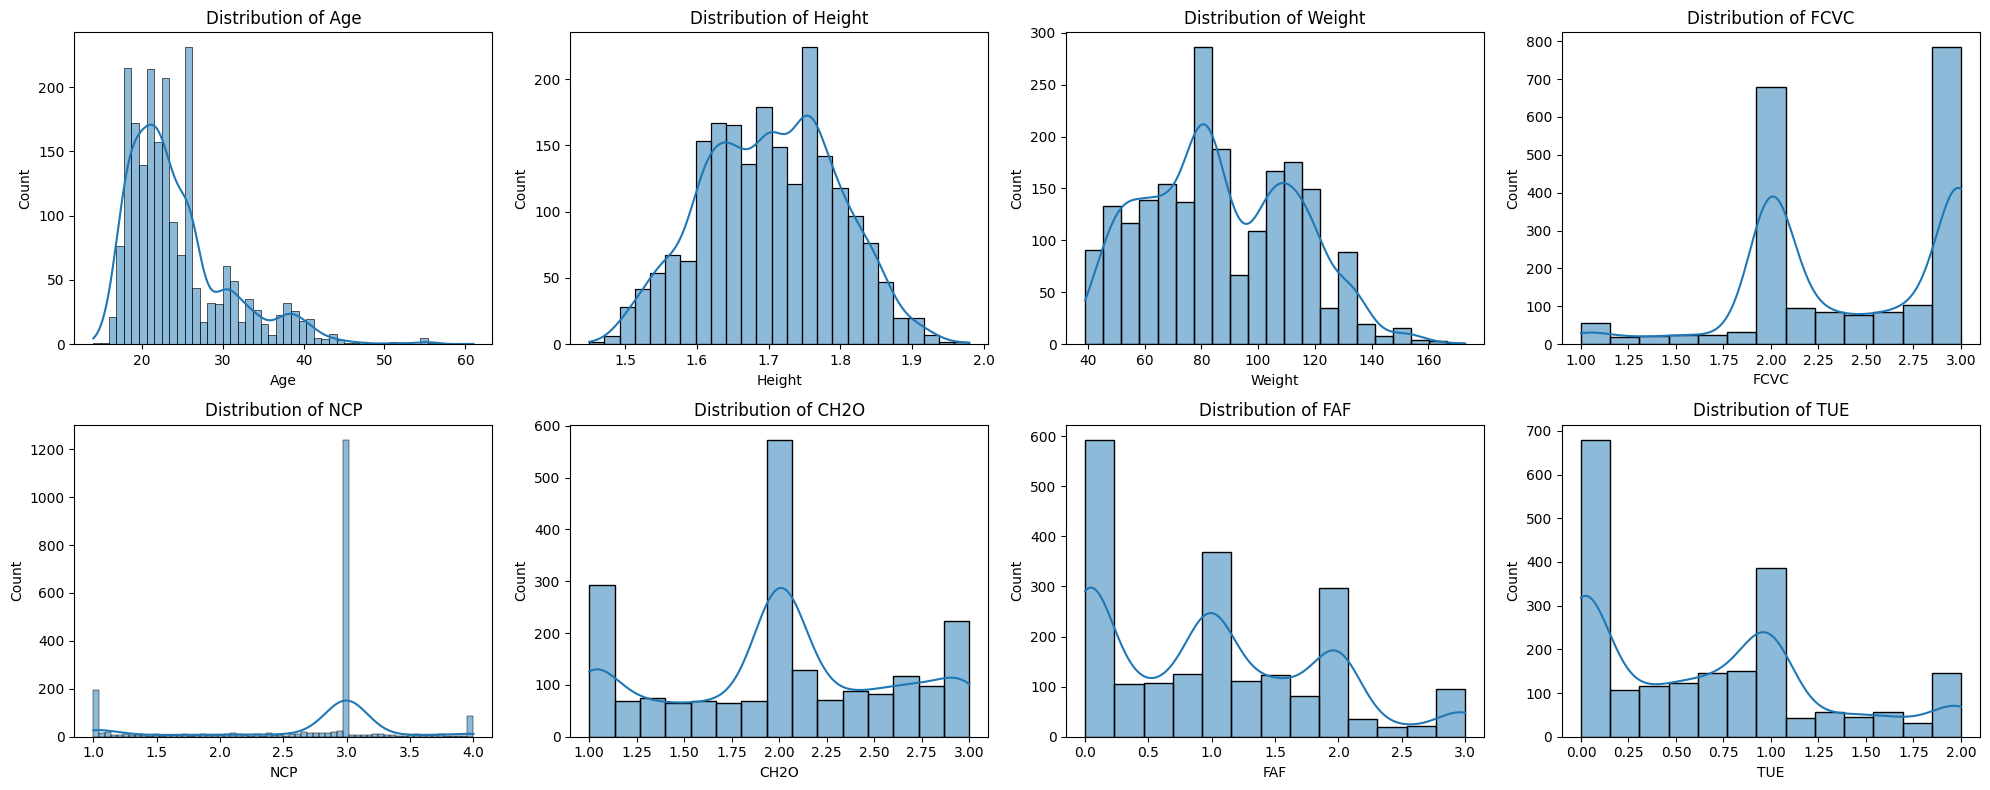

In [37]:
categorical_cols = ['Gender', 'CALC', 'FAVC', 'SCC', 'SMOKE', 'family_history_with_overweight', 'CAEC', 'MTRANS']
figure, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig("C:\\AC Office Chakwal\\Python\\obesitychecker project\\dataset\\univariate_numerical.png")
plt.show()

### Univariate Analysis Between Categorical Columns

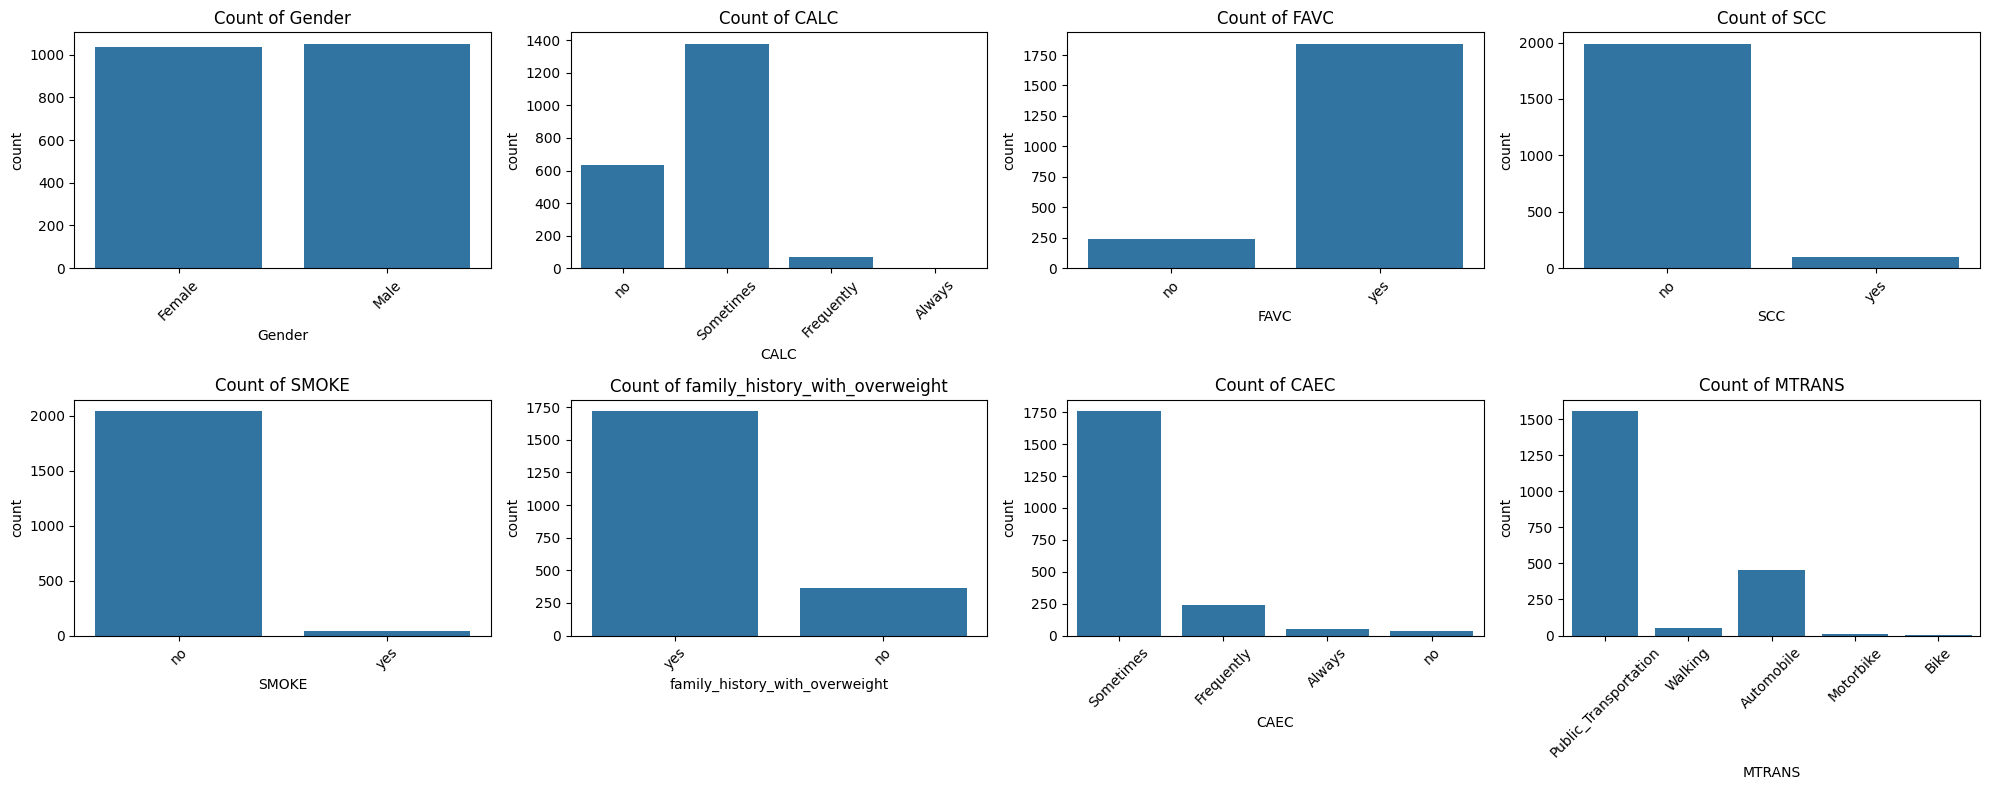

In [38]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Count of {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig("C:\\AC Office Chakwal\\Python\\obesitychecker project\\dataset\\univariate_categorical.png")
plt.show()

### TARGET VARIABLE DISTRIBUTION

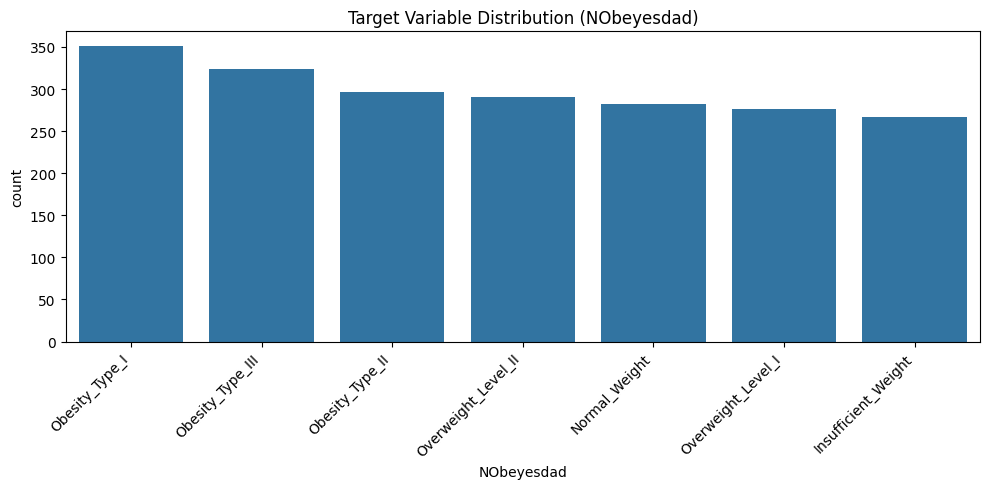

In [39]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='NObeyesdad', order=df['NObeyesdad'].value_counts().index)
plt.title('Target Variable Distribution (NObeyesdad)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("C:\\AC Office Chakwal\\Python\\obesitychecker project\\dataset\\target_distribution.png")
plt.show()

#### Corelation Heat Map Between Numerical Categories 

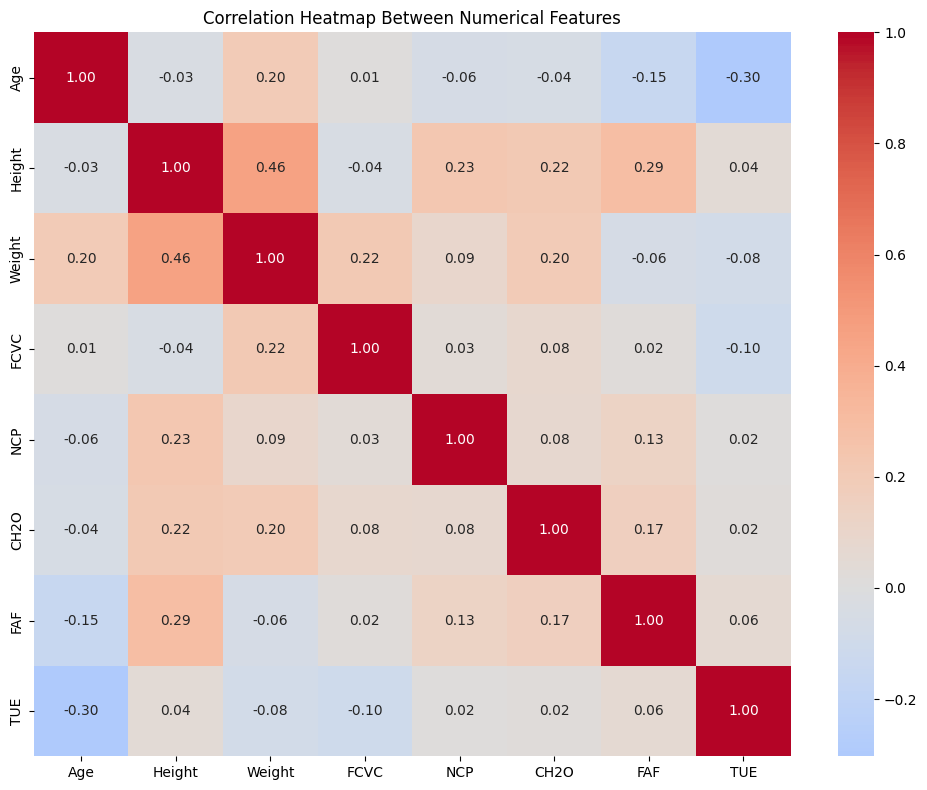

In [40]:
plt.figure(figsize=(10, 8))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Heatmap Between Numerical Features')
plt.tight_layout()
plt.savefig("C:\\AC Office Chakwal\\Python\\obesitychecker project\\dataset\\correlation_heatmap.png")
plt.show()

### NUMERICAL FEATURES vs TARGET (boxplots)

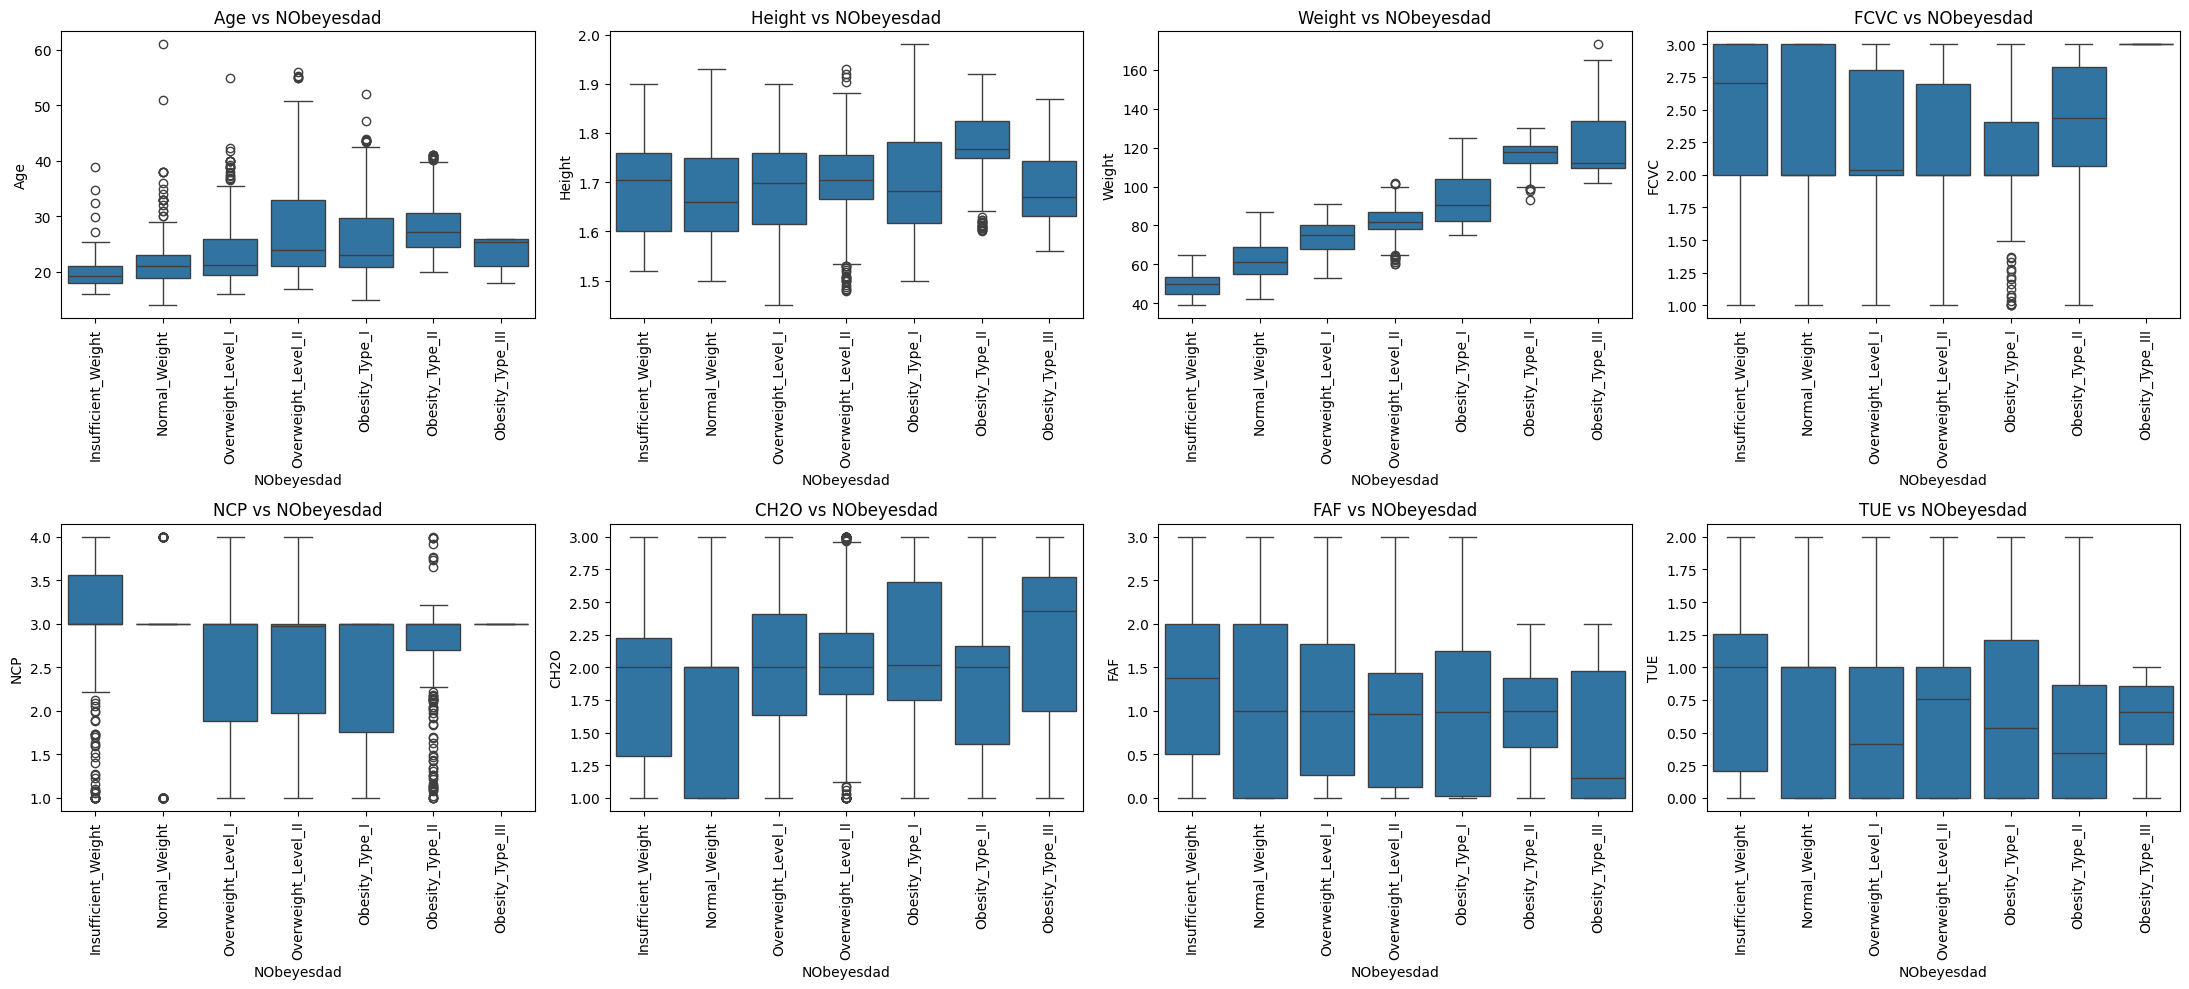

In [41]:
target_order = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I',
                 'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='NObeyesdad', y=col, order=target_order, ax=axes[i])
    axes[i].set_title(f'{col} vs NObeyesdad')
    axes[i].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.savefig("C:\\AC Office Chakwal\\Python\\obesitychecker project\\dataset\\numerical_vs_target.png")
plt.show()

### Categorical Features vs Target (boxplots)

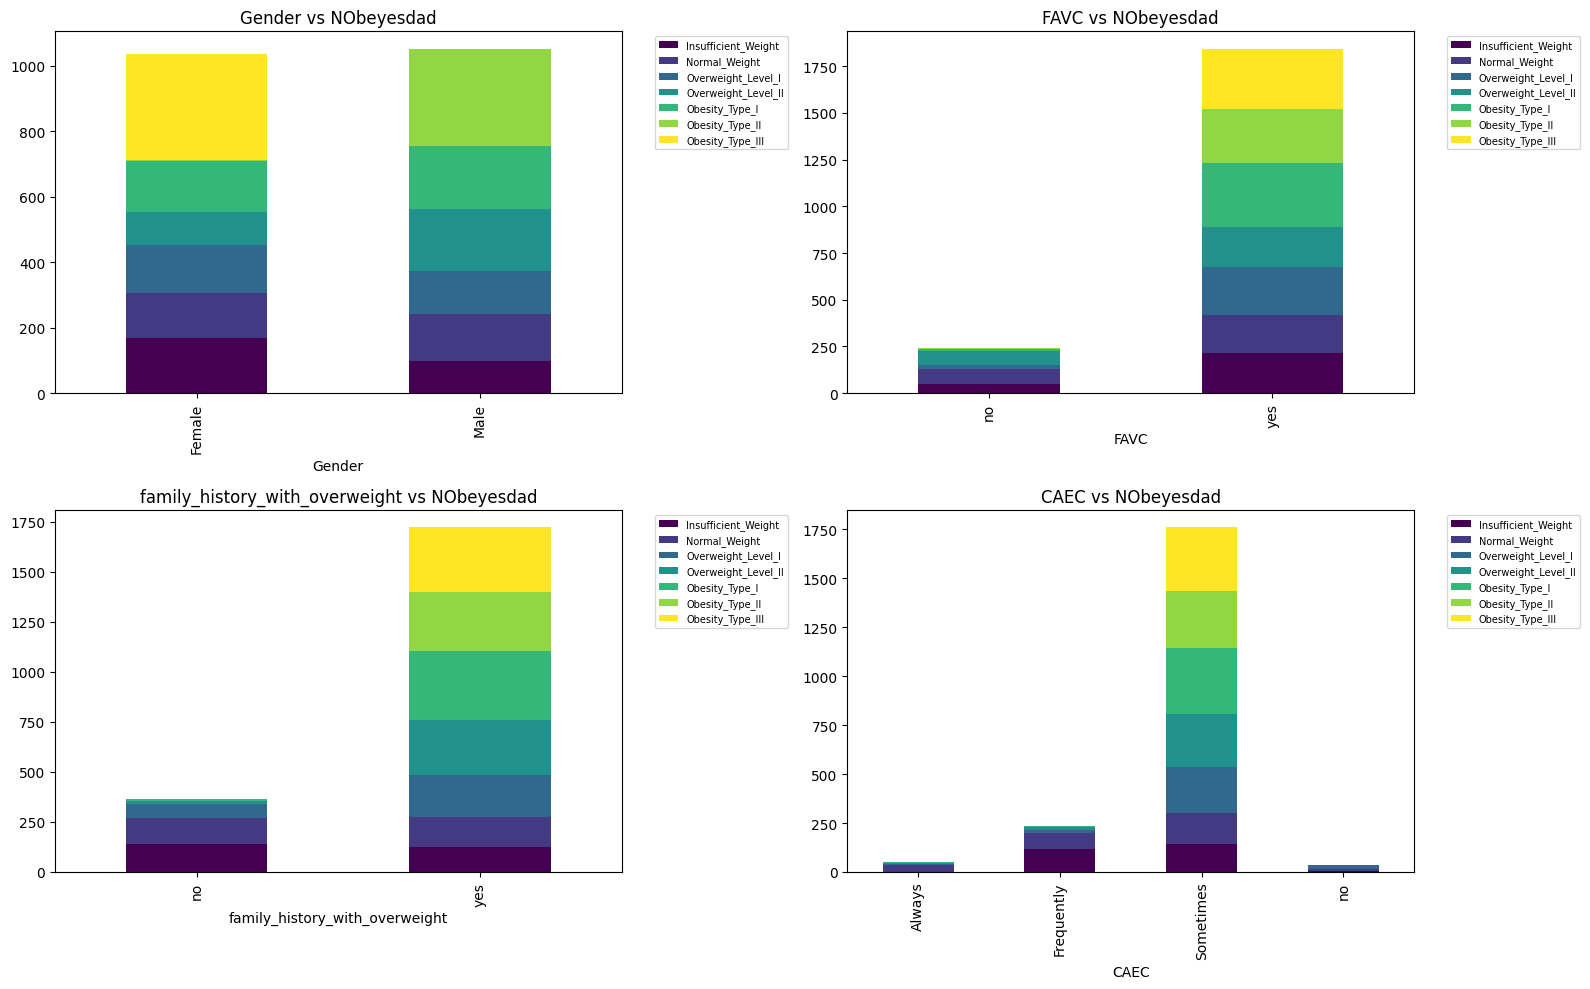

In [42]:
categorical_cols = ['Gender', 'FAVC', 'family_history_with_overweight', 'CAEC']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df['NObeyesdad'])
    ct = ct[target_order]  # order columns
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis')
    axes[i].set_title(f'{col} vs NObeyesdad')
    axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.savefig("C:\\AC Office Chakwal\\Python\\obesitychecker project\\dataset\\categorical_vs_target.png")
plt.show()

### Key Numerical Summary

In [43]:
print("--- Mean values of numerical features per obesity class ---")
print(df.groupby('NObeyesdad')[numerical_cols].mean().reindex(target_order))

--- Mean values of numerical features per obesity class ---
                           Age    Height      Weight      FCVC       NCP  \
NObeyesdad                                                                 
Insufficient_Weight  19.771687  1.693572   50.013190  2.474811  2.942763   
Normal_Weight        21.758865  1.676950   62.164894  2.336879  2.748227   
Overweight_Level_I   23.540309  1.691277   74.483261  2.278055  2.580519   
Overweight_Level_II  26.996981  1.703748   82.085271  2.260578  2.495529   
Obesity_Type_I       25.884941  1.693804   92.870198  2.186050  2.431862   
Obesity_Type_II      28.233785  1.771795  115.305311  2.391284  2.744555   
Obesity_Type_III     23.495554  1.687559  120.941114  3.000000  3.000000   

                         CH2O       FAF       TUE  
NObeyesdad                                         
Insufficient_Weight  1.883852  1.273542  0.847689  
Normal_Weight        1.858156  1.251773  0.677305  
Overweight_Level_I   2.010979  1.059677  0.6440

#### Feature Engineering

In [44]:
df['BMI'] = df['Weight'] / (df['Height'] ** 2)

print("--- BMI Statistics ---")
print(df['BMI'].describe())

--- BMI Statistics ---
count    2087.000000
mean       29.765758
std         8.024934
min        12.998685
25%        24.368897
50%        28.896224
75%        36.095538
max        50.811753
Name: BMI, dtype: float64


In [45]:
print("\n--- Mean BMI per obesity class ---")
target_order = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I',
                 'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
print(df.groupby('NObeyesdad')['BMI'].mean().reindex(target_order))


--- Mean BMI per obesity class ---
NObeyesdad
Insufficient_Weight    17.390730
Normal_Weight          22.007841
Overweight_Level_I     25.956179
Overweight_Level_II    28.215232
Obesity_Type_I         32.255636
Obesity_Type_II        36.723424
Obesity_Type_III       42.273746
Name: BMI, dtype: float64


### Feature Encoding

#### Binary Encoding on Numerical Values

In [46]:
binary_cols = ['Gender', 'FAVC', 'SCC', 'SMOKE', 'family_history_with_overweight']

df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df['FAVC'] = df['FAVC'].map({'no': 0, 'yes': 1})
df['SCC'] = df['SCC'].map({'no': 0, 'yes': 1})
df['SMOKE'] = df['SMOKE'].map({'no': 0, 'yes': 1})
df['family_history_with_overweight'] = df['family_history_with_overweight'].map({'no': 0, 'yes': 1})
print("Binary columns after encoding:\n", df[binary_cols].head())

Binary columns after encoding:
    Gender  FAVC  SCC  SMOKE  family_history_with_overweight
0       0     0    0      0                               1
1       0     0    1      1                               1
2       1     0    0      0                               1
3       1     0    0      0                               0
4       1     0    0      0                               0


#### Ordinal Encoding 

In [47]:
df['CALC'] = df['CALC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})
df['CAEC'] = df['CAEC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})
print("Ordinal columns after encoding:", df[['CALC', 'CAEC']].head())

Ordinal columns after encoding:    CALC  CAEC
0     0     1
1     1     1
2     2     1
3     2     1
4     1     1


#### One Hot Encoding on Feature MTRANS

In [48]:
df = pd.get_dummies(df, columns=['MTRANS'], prefix='MTRANS')
print("Dummy columns after encoding:\n", df.filter(regex='MTRANS_').head())

Dummy columns after encoding:
    MTRANS_Automobile  MTRANS_Bike  MTRANS_Motorbike  \
0              False        False             False   
1              False        False             False   
2              False        False             False   
3              False        False             False   
4              False        False             False   

   MTRANS_Public_Transportation  MTRANS_Walking  
0                          True           False  
1                          True           False  
2                          True           False  
3                         False            True  
4                          True           False  


#### Ordinal Labeled Encoding on Target Variable

In [49]:
df['NObeyesdad'] = df['NObeyesdad'].map({
    'Insufficient_Weight': 0,
    'Normal_Weight': 1,
    'Overweight_Level_I': 2,
    'Overweight_Level_II': 3,
    'Obesity_Type_I': 4,
    'Obesity_Type_II': 5,
    'Obesity_Type_III': 6
})
print("Target variable after encoding:\n", df['NObeyesdad'].head())

Target variable after encoding:
 0    1
1    1
2    1
3    2
4    3
Name: NObeyesdad, dtype: int64


### Shape of the data set after encoding

In [50]:
print(df.head())
print("\nNew shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)

    Age  Gender  Height  Weight  CALC  FAVC  FCVC  NCP  SCC  SMOKE  ...  FAF  \
0  21.0       0    1.62    64.0     0     0   2.0  3.0    0      0  ...  0.0   
1  21.0       0    1.52    56.0     1     0   3.0  3.0    1      1  ...  3.0   
2  23.0       1    1.80    77.0     2     0   2.0  3.0    0      0  ...  2.0   
3  27.0       1    1.80    87.0     2     0   3.0  3.0    0      0  ...  2.0   
4  22.0       1    1.78    89.8     1     0   2.0  1.0    0      0  ...  0.0   

   TUE  CAEC  NObeyesdad        BMI  MTRANS_Automobile  MTRANS_Bike  \
0  1.0     1           1  24.386526              False        False   
1  0.0     1           1  24.238227              False        False   
2  1.0     1           1  23.765432              False        False   
3  0.0     1           2  26.851852              False        False   
4  0.0     1           3  28.342381              False        False   

   MTRANS_Motorbike  MTRANS_Public_Transportation  MTRANS_Walking  
0             False     

#### Convert MTRANS bool columns to int (0/1) so that the simalarity remains in the data set

In [51]:

mtrans_cols = [col for col in df.columns if col.startswith('MTRANS_')]
df[mtrans_cols] = df[mtrans_cols].astype(int)

print(df.dtypes)

Age                               float64
Gender                              int64
Height                            float64
Weight                            float64
CALC                                int64
FAVC                                int64
FCVC                              float64
NCP                               float64
SCC                                 int64
SMOKE                               int64
CH2O                              float64
family_history_with_overweight      int64
FAF                               float64
TUE                               float64
CAEC                                int64
NObeyesdad                          int64
BMI                               float64
MTRANS_Automobile                   int64
MTRANS_Bike                         int64
MTRANS_Motorbike                    int64
MTRANS_Public_Transportation        int64
MTRANS_Walking                      int64
dtype: object


### Feature Scaling

In [52]:
Columns_that_need_to_be_scaled = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE','BMI']
scaler = StandardScaler()

# Scaled result ko WAPAS df mein assign karo
df[Columns_that_need_to_be_scaled] = scaler.fit_transform(df[Columns_that_need_to_be_scaled])

print("Scaled features shape:", df[Columns_that_need_to_be_scaled].shape)
print(df[Columns_that_need_to_be_scaled].describe())

Scaled features shape: (2087, 9)
                Age        Height        Weight          FCVC           NCP  \
count  2.087000e+03  2.087000e+03  2.087000e+03  2.087000e+03  2.087000e+03   
mean  -1.634214e-16  8.851994e-16 -5.447381e-17 -5.447381e-16  1.736353e-16   
std    1.000240e+00  1.000240e+00  1.000240e+00  1.000240e+00  1.000240e+00   
min   -1.625984e+00 -2.712155e+00 -1.827745e+00 -2.658892e+00 -2.225418e+00   
25%   -6.968683e-01 -7.781538e-01 -7.966038e-01 -7.883642e-01 -4.856048e-03   
50%   -2.364389e-01 -1.170116e-02 -1.435055e-01 -4.713949e-02  3.909061e-01   
75%    2.586523e-01  7.172047e-01  8.080017e-01  1.082164e+00  3.909061e-01   
max    5.755509e+00  2.976762e+00  3.289772e+00  1.082164e+00  1.699068e+00   

               CH2O           FAF           TUE           BMI  
count  2.087000e+03  2.087000e+03  2.087000e+03  2.087000e+03  
mean   4.085536e-16  2.587506e-16 -1.089476e-16  5.992119e-16  
std    1.000240e+00  1.000240e+00  1.000240e+00  1.000240e+00  

In [53]:
print("\n--- Final dataset ready for modeling ---")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nAny nulls?", df.isnull().sum().sum())


--- Final dataset ready for modeling ---
Shape: (2087, 22)

Columns: ['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'NObeyesdad', 'BMI', 'MTRANS_Automobile', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']

Dtypes:
 Age                               float64
Gender                              int64
Height                            float64
Weight                            float64
CALC                                int64
FAVC                                int64
FCVC                              float64
NCP                               float64
SCC                                 int64
SMOKE                               int64
CH2O                              float64
family_history_with_overweight      int64
FAF                               float64
TUE                               float64
CAEC                                int64
NObeyesdad    

#### Train Test Split

In [54]:
# X = features (target column ko alag kiya)
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # reproducibility ke liye
    stratify=y            # IMPORTANT: har class ka proportion same rahe train/test mein
)
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

print("\n--- Train set class distribution ---")
print(y_train.value_counts(normalize=True).sort_index())

print("\n--- Test set class distribution ---")
print(y_test.value_counts(normalize=True).sort_index())

Training set shape: (1669, 21) (1669,)
Testing set shape: (418, 21) (418,)

--- Train set class distribution ---
NObeyesdad
0    0.128220
1    0.134811
2    0.132415
3    0.139005
4    0.168364
5    0.142001
6    0.155183
Name: proportion, dtype: float64

--- Test set class distribution ---
NObeyesdad
0    0.126794
1    0.136364
2    0.131579
3    0.138756
4    0.167464
5    0.143541
6    0.155502
Name: proportion, dtype: float64


#### Class Imbalance Check

In [55]:
from collections import Counter

# -----------------------------
# STEP 11: CLASS IMBALANCE CHECK
# -----------------------------
print("--- Training set class counts ---")
print(Counter(y_train))

print("\n--- Imbalance ratio ---")
counts = y_train.value_counts()
imbalance_ratio = counts.max() / counts.min()
print(f"Max class: {counts.max()}, Min class: {counts.min()}")
print(f"Imbalance ratio: {imbalance_ratio:.2f} : 1")

if imbalance_ratio < 1.5:
    print("\n✅ Decision: Dataset is well-balanced. No SMOTE/resampling needed.")
else:
    print("\n⚠️ Decision: Consider SMOTE or class_weight='balanced' in model.")

--- Training set class counts ---
Counter({4: 281, 6: 259, 5: 237, 3: 232, 1: 225, 2: 221, 0: 214})

--- Imbalance ratio ---
Max class: 281, Min class: 214
Imbalance ratio: 1.31 : 1

✅ Decision: Dataset is well-balanced. No SMOTE/resampling needed.


#### Model Selection (Logistic Regression)

In [58]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression


lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)



,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

#### Evaluate the model on the test set

In [60]:
y_pred_lr = lr_model.predict(X_test)
print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION RESULTS
Accuracy: 0.8995

Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        53
           1       0.96      0.81      0.88        57
           2       0.76      0.80      0.78        55
           3       0.81      0.79      0.80        58
           4       0.96      0.91      0.93        70
           5       0.91      0.98      0.94        60
           6       0.98      0.98      0.98        65

    accuracy                           0.90       418
   macro avg       0.90      0.90      0.90       418
weighted avg       0.90      0.90      0.90       418



#### Confusion Matrix

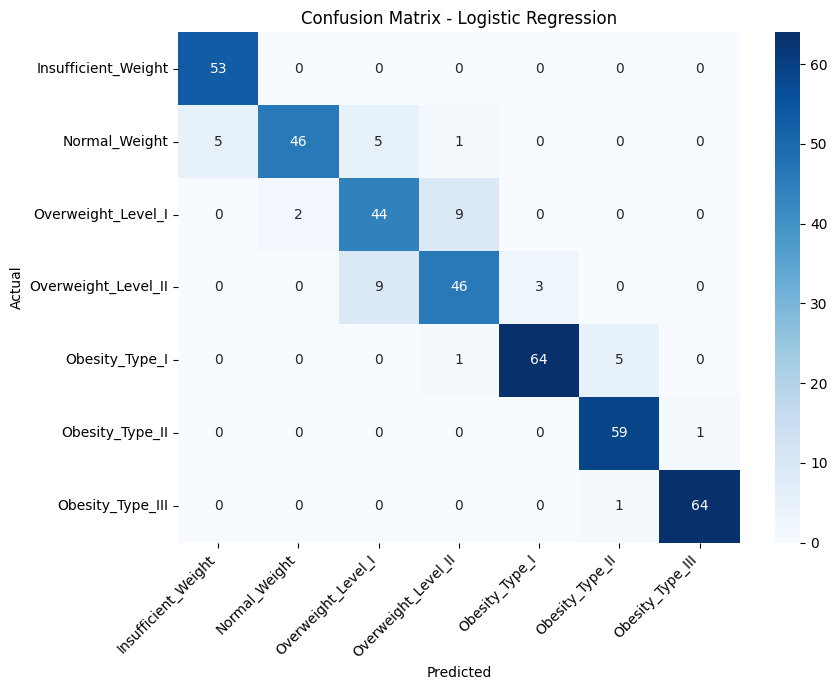

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


class_names = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I',
               'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("C:\\AC Office Chakwal\\Python\\obesitychecker project\\dataset\\confusion_matrix_lr.png")
plt.show()

#### Model Selection (Random Forest)

In [63]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

#### Evaluate the model on the test set

In [64]:
y_pred_rf = rf_model.predict(X_test)

print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST RESULTS
Accuracy: 0.9904

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.97      1.00      0.98        57
           2       1.00      0.96      0.98        55
           3       1.00      1.00      1.00        58
           4       1.00      1.00      1.00        70
           5       0.98      0.98      0.98        60
           6       0.98      0.98      0.98        65

    accuracy                           0.99       418
   macro avg       0.99      0.99      0.99       418
weighted avg       0.99      0.99      0.99       418



#### Confusion Matrix

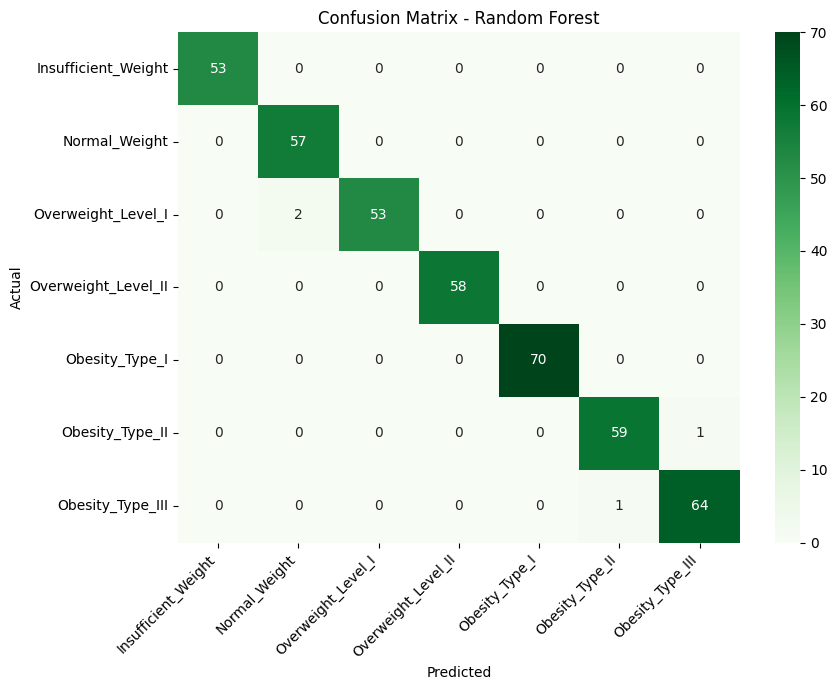

In [65]:

class_names = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I',
               'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("C:\\AC Office Chakwal\\Python\\obesitychecker project\\dataset\\confusion_matrix_rf.png")
plt.show()

#### XG BOOST

In [66]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

#### evaluation of XG Boost

In [67]:
y_pred_xgb = xgb_model.predict(X_test)

print("=" * 50)
print("XGBOOST RESULTS")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBOOST RESULTS
Accuracy: 0.9833

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        53
           1       0.97      0.98      0.97        57
           2       1.00      0.95      0.97        55
           3       0.97      1.00      0.98        58
           4       1.00      1.00      1.00        70
           5       0.98      0.98      0.98        60
           6       0.98      0.98      0.98        65

    accuracy                           0.98       418
   macro avg       0.98      0.98      0.98       418
weighted avg       0.98      0.98      0.98       418



#### Confusion Matrix of XG BOOST

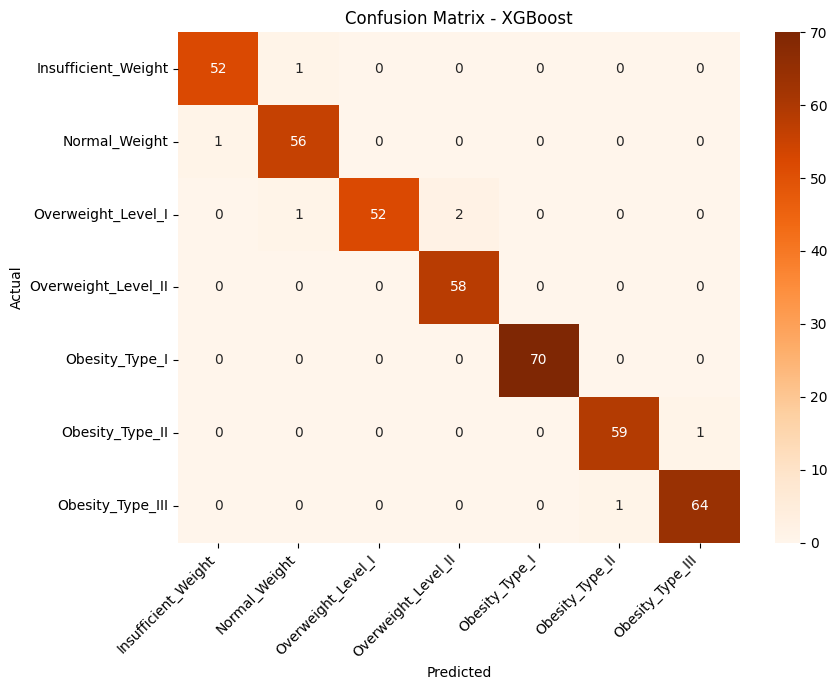

In [69]:
class_names = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I',
               'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("C:\\AC Office Chakwal\\Python\\obesitychecker project\\dataset\\confusion_matrix_xgb.png")
plt.show()

#### Hyper Parameter Tuning on Random Forest Model

In [71]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_base = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,                  # 5-fold cross validation
    scoring='accuracy',
    n_jobs=-1,             # sab CPU cores use karo (fast)
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters found: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation accuracy: 0.9880149610688533


In [72]:
best_rf_model = grid_search.best_estimator_

#### evaluation/prediction of test data on best model 

In [73]:
y_pred_best = best_rf_model.predict(X_test)

print("=" * 50)
print("TUNED RANDOM FOREST - FINAL TEST RESULTS")
print("=" * 50)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))



TUNED RANDOM FOREST - FINAL TEST RESULTS
Test Accuracy: 0.9952

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.98      1.00      0.99        57
           2       1.00      0.98      0.99        55
           3       1.00      1.00      1.00        58
           4       1.00      1.00      1.00        70
           5       1.00      0.98      0.99        60
           6       0.98      1.00      0.99        65

    accuracy                           1.00       418
   macro avg       1.00      1.00      1.00       418
weighted avg       1.00      1.00      1.00       418



#### Confusion Matrix

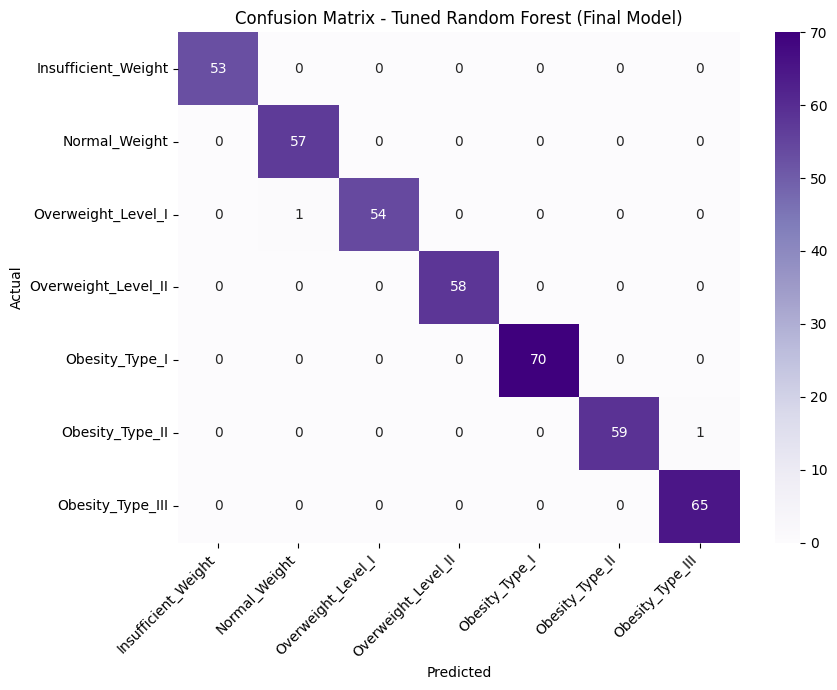

In [75]:
class_names = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I',
               'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Tuned Random Forest (Final Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("C:\\AC Office Chakwal\\Python\\obesitychecker project\\dataset\\confusion_matrix_final.png")
plt.show()

#### Feature Importance

C:\Users\pc\AppData\Local\Temp\ipykernel_4952\1448128872.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')


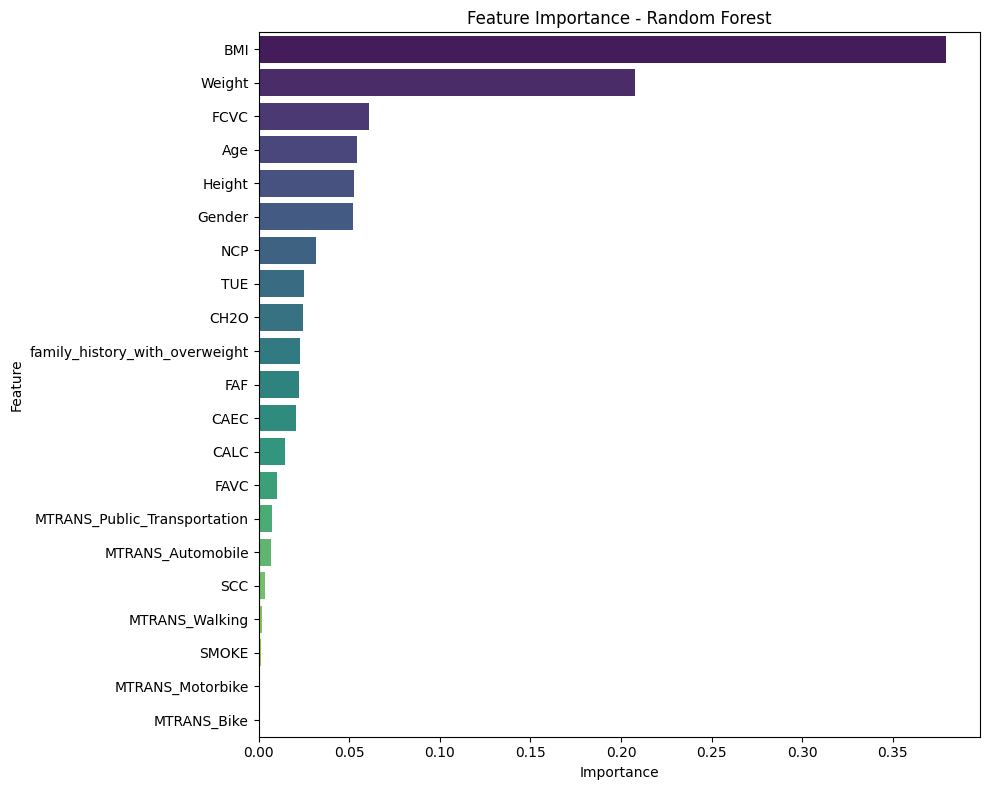


--- Top 5 Most Important Features ---
   Feature  Importance
15     BMI    0.379132
3   Weight    0.207677
6     FCVC    0.060902
0      Age    0.054314
2   Height    0.052656


In [77]:
importances = best_rf_model.feature_importances_
feature_names = X_train.columns

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.savefig("C:\\AC Office Chakwal\\Python\\obesitychecker project\\dataset\\feature_importance.png")
plt.show()

print("\n--- Top 5 Most Important Features ---")
print(feat_imp_df.head())

#### Model Save

In [79]:
import joblib

# -----------------------------
# STEP 16: MODEL SAVING & DEPLOYMENT PREP
# -----------------------------

# 1. Trained model save karo
joblib.dump(best_rf_model, 'C:\\AC Office Chakwal\\Python\\obesitychecker project\\dataset\\obesity_rf_model.pkl')
print("✅ Model saved: obesity_rf_model.pkl")

# 2. Scaler save karo (future predictions ke liye zaroori - same scaling apply karni hogi)
joblib.dump(scaler, 'C:\\AC Office Chakwal\\Python\\obesitychecker project\\dataset\\scaler.pkl')
print("✅ Scaler saved: scaler.pkl")

# 3. Encoding mappings save karo (dictionary ke taur pe, taake naye data ko encode kar sakein)
encoding_mappings = {
    'target_order': {
        0: 'Insufficient_Weight', 1: 'Normal_Weight', 2: 'Overweight_Level_I',
        3: 'Overweight_Level_II', 4: 'Obesity_Type_I', 5: 'Obesity_Type_II',
        6: 'Obesity_Type_III'
    },
    'calc_caec_order': {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3},
    'gender_map': {'Female': 0, 'Male': 1},
    'binary_map': {'no': 0, 'yes': 1},
    'feature_columns': X_train.columns.tolist(),   # exact column order model expects
    'scaled_columns': ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']
}
joblib.dump(encoding_mappings, 'C:\\AC Office Chakwal\\Python\\obesitychecker project\\dataset\\encoding_mappings.pkl')
print("✅ Encoding mappings saved: encoding_mappings.pkl")

print("\n🎉 All artifacts saved in ../models/ folder!")

✅ Model saved: obesity_rf_model.pkl
✅ Scaler saved: scaler.pkl
✅ Encoding mappings saved: encoding_mappings.pkl

🎉 All artifacts saved in ../models/ folder!
